# introducion a Nave Bayes

- ¿Lleva poco tiempo como cliente?
- ¿tiene contrato mes a mes?
- ¿paga mucho por el servicio?
- ¿ha llamado muchas veces asoporte?


## ¿Por que se llama "Naive" (ingenuo)?

El modelo asume que **Todas las variables** son independientes entre si, Es decir que asume que:

- El tipo de contratoNo influye en el gastomensual
- La antiguedad No influye si tiene un soporte tecnico
- El genero NO influye sobre el métodode pago


In [13]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, recall_score, precision_score, f1_score)

sns. set_style('whitegrid')
np.random.seed(42)


In [14]:
df = pd.read_csv('Telco-Customer-Churn.csv')

df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})



print(f"Dataset: {len(df)} clientes")
print(f"Churn: {df['Churn'].mean()*100:.1f}%")

Dataset: 7032 clientes
Churn: 26.6%


In [15]:
#Codificar variables categoricas
df_encode =pd.get_dummies( df, columns= df.select_dtypes(include='object').columns, drop_first=True)

#separar variables predictoras y variable objetivo (x e y)
X = df_encode.drop('Churn', axis=1)
y = df_encode['Churn']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify= y)


# Escalar los datos

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f" Datos de entrenamiento: {X_train.shape [0]} registros")
print(f" Datos de prueba: {X_test.shape [0]} registros")
print(f" Variables : {X_train.shape [1]}")

 Datos de entrenamiento: 5625 registros
 Datos de prueba: 1407 registros
 Variables : 30


In [16]:
import time

# Entrenar Naive Bayes y medir el tiempo

inicio = time.time()
modelo_nb = GaussianNB()
modelo_nb.fit(X_train, y_train)
tiempo_entrenamiento = time.time() - inicio

print(f"Modelo entrenado en {tiempo_entrenamiento*1000:.2f} ms")
print(f"\nClases aprendidas: {modelo_nb.classes_}")
print(f"Probabilidad base de cada clase:")
print(f" Permanece (0): {modelo_nb.class_prior_[0]*100:.1f}%")
print(f" Abandona (1): {modelo_nb.class_prior_[1]*100:.1f}%")

Modelo entrenado en 20.97 ms

Clases aprendidas: [0 1]
Probabilidad base de cada clase:
 Permanece (0): 73.4%
 Abandona (1): 26.6%


In [17]:
# Hacer predicciones
y_pred = modelo_nb.predict(X_test)

# Evaluar
print("\nRESULTADOS DE NAIVE BAYES:")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}%")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f" F1 Score: {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"{classification_report(y_test, y_pred, target_names=['Permanece (0)', 'Abandona (1)'], zero_division=0)}")


RESULTADOS DE NAIVE BAYES:
Accuracy: 0.6446%
Precision: 0.4184
Recall: 0.8636
 F1 Score: 0.5637
               precision    recall  f1-score   support

Permanece (0)       0.92      0.57      0.70      1033
 Abandona (1)       0.42      0.86      0.56       374

     accuracy                           0.64      1407
    macro avg       0.67      0.71      0.63      1407
 weighted avg       0.79      0.64      0.66      1407



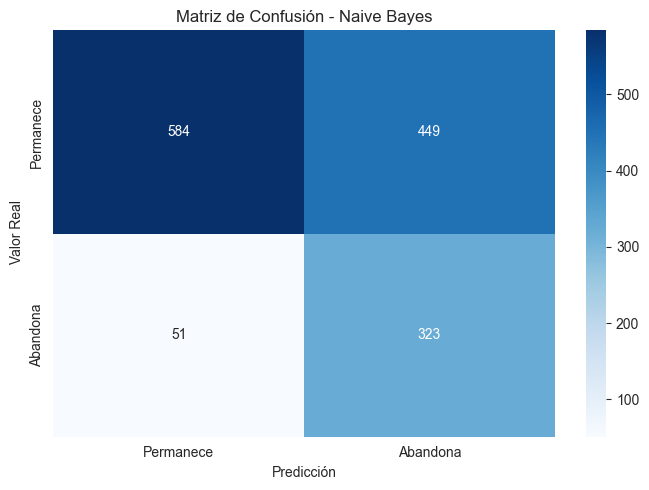

Interpretacion
 Clientes que NO se fueron y el modeloacerto (TN): 584
 Clientes que se fueron y el modeloacerto (TP): 323
 Clientes que NO se fueron pero el modelo predijo que se fueron (FP): 449
 Clientes que se fueron pero el modelo predijo que NO se fueron (FN): 51


In [ ]:
#visualizar matriz de confusión

fig , ax = plt.subplots(figsize=(7,5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Permanece', 'Abandona'],
            yticklabels=['Permanece', 'Abandona'])
ax.set_title('Matriz de Confusión - Naive Bayes')
ax.set_xlabel('Predicción')
ax.set_ylabel(' Valor Real')

plt.tight_layout()
plt.show()

# Interpretar los numeros de la matriz de confusión
tn, fp, fn, tp = cm.ravel()
print(f"Interpretacion")
print(f" Clientes que NO se fueron y el modelo acerto (TN): {tn}")
print(f" Clientes que se fueron y el modelo acerto (TP): {tp}")
print(f" Clientes que NO se fueron pero el modelo predijo que se fueron (FP): {fp}")
print(f" Clientes que se fueron pero el modelo predijo que NO se fueron (FN): {fn}")

In [20]:
# Obtener las probabilidades de cada prediccion
probabilidades = modelo_nb.predict_proba(X_test)

# Crear un DataFrame con los resultados
df_proba = pd.DataFrame({
    'Prob_No_Churn': probabilidades[:, 0],
    'Prob_Churn': probabilidades[:, 1],
    'Prediccion': y_pred,
    'Valor_Real': y_test.values
})

print("Primeros 10 clientes con sus probabilidades:")
print("(El modelo predice Churn cuando Prob_Churn > 0.5)")
df_proba.head(10).round(4)

Primeros 10 clientes con sus probabilidades:
(El modelo predice Churn cuando Prob_Churn > 0.5)


,Prob_No_Churn,Prob_Churn,Prediccion,Valor_Real
0,1.0000,0.0000,0,0
1,0.0000,1.0000,1,0
2,1.0000,0.0000,0,0
3,1.0000,0.0000,0,1
4,1.0000,0.0000,0,0
5,0.0006,0.9994,1,1
6,1.0000,0.0000,0,0
7,1.0000,0.0000,0,0
8,0.0001,0.9999,1,1
9,1.0000,0.0000,0,0


In [21]:
# Los 10 clientes con MAYOR probabilidad de churn
print("TOP 10 clientes con mayor riesgo de churn:")
print("(Estos son los que la empresa deberia contactar primero)")
print()
df_proba.nlargest(10, 'Prob_Churn')[['Prob_Churn', 'Valor_Real']].round(4)

TOP 10 clientes con mayor riesgo de churn:
(Estos son los que la empresa deberia contactar primero)



,Prob_Churn,Valor_Real
211,1.0,0
1261,1.0,0
1080,1.0,1
1376,1.0,1
346,1.0,1
715,1.0,1
1077,1.0,0
1149,1.0,1
1254,1.0,1
464,1.0,1


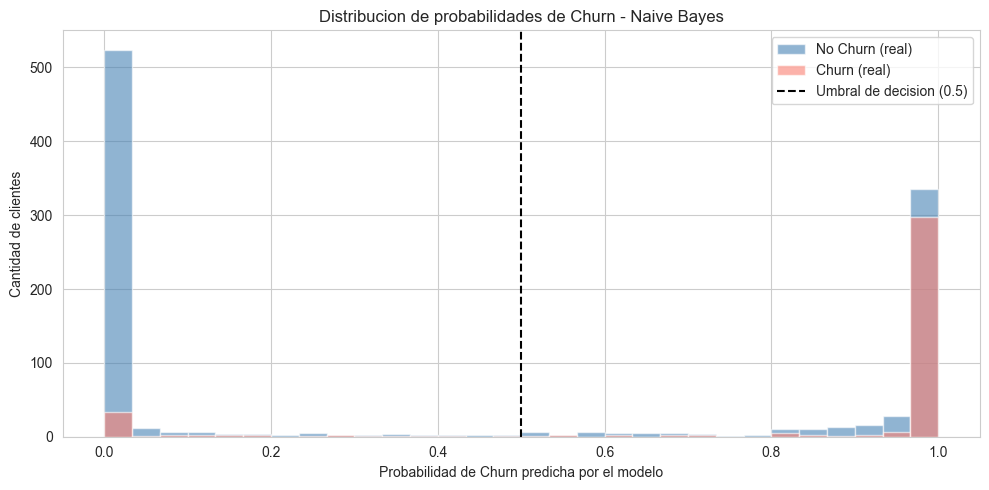

Si las distribuciones estan bien separadas, el modelo distingue bien.
Si se solapan mucho, al modelo le cuesta diferenciar churn de no churn.


In [22]:
# Distribucion de probabilidades de churn
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_proba[df_proba['Valor_Real'] == 0]['Prob_Churn'],
        bins=30, alpha=0.6, label='No Churn (real)', color='steelblue')
ax.hist(df_proba[df_proba['Valor_Real'] == 1]['Prob_Churn'],
        bins=30, alpha=0.6, label='Churn (real)', color='salmon')
ax.axvline(x=0.5, color='black', linestyle='--', label='Umbral de decision (0.5)')
ax.set_xlabel('Probabilidad de Churn predicha por el modelo')
ax.set_ylabel('Cantidad de clientes')
ax.set_title('Distribucion de probabilidades de Churn - Naive Bayes')
ax.legend()

plt.tight_layout()
plt.show()

print("Si las distribuciones estan bien separadas, el modelo distingue bien.")
print("Si se solapan mucho, al modelo le cuesta diferenciar churn de no churn.")

In [23]:
from sklearn.linear_model import LogisticRegression

# Medir tiempo de Naive Bayes
inicio = time.time()
GaussianNB().fit(X_train, y_train)
tiempo_nb = time.time() - inicio

# Medir tiempo de Logistic Regression
inicio = time.time()
LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced').fit(X_train, y_train)
tiempo_lr = time.time() - inicio

print("COMPARACION DE VELOCIDAD")
print("=" * 40)
print(f"  Naive Bayes:         {tiempo_nb*1000:.2f} ms")
print(f"  Logistic Regression: {tiempo_lr*1000:.2f} ms")
print(f"\n  Naive Bayes es {tiempo_lr/tiempo_nb:.1f}x mas rapido")

COMPARACION DE VELOCIDAD
  Naive Bayes:         19.66 ms
  Logistic Regression: 92.02 ms

  Naive Bayes es 4.7x mas rapido
